# Generation parameter sweep: forbidden fraction × transition count

This notebook sweeps two parameters of the 2-D board generation process while holding
`k=3`, `alphabet_size=8`, and `dimensions=2` fixed:

* **`forbidden_fraction`** – probability that each k-gram is forbidden; controls
  grammar density / language difficulty.
* **`target_transition_count`** (transitions) – how many board steps to generate per scenario.

For each combination we measure:

1. **Generation time** – wall time up to a configurable hard timeout.
2. **Outcome** – success, timeout, or generation error (e.g. grammar too restrictive to
   place any more tokens).
3. **Prompt size** – character count of the final-step user+system prompt (the largest
   prompt in the scenario), used as an LLM cost proxy.

Goal: identify a good default `forbidden_fraction` and an upper ceiling for
`target_transition_count`.

In [10]:
import time
import tempfile
import warnings

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.patches import Patch
from pathlib import Path
import numpy as np
import pandas as pd
import tiktoken

warnings.filterwarnings("ignore", category=FutureWarning)

from src.formal.grammar.alphabet import LetterAlphabetSampler
from src.formal.grammar.config import AutoResampleConfig, SLSamplingConfig
from src.formal.grammar.sampler import sample_sl_grammar
from src.formal.grammar.serialization import save_grammar
from src.generator.config import GeneratorConfig, load_generator_config
from src.generator.engine import GenerationError, ScenarioGenerator
from src.generator.reconstruction import reconstruct_boards
from src.llm.prompting import build_prompt
from src.llm.representers import RepresenterConfig

In [11]:
# ── Fixed parameters ──────────────────────────────────────────────────────────
K = 3
DIMENSIONS = 2
ALPHABET_SIZE = 8
MIN_WORD_LENGTH = 3

# ── Sweep grid ────────────────────────────────────────────────────────────────
FORBIDDEN_FRACTIONS = [0.25, 0.5, 0.75]
TRANSITION_COUNTS   = [25, 75, 200, 450, 900]

# ── Multi-seed configuration ──────────────────────────────────────────────────
# Set N_SEEDS=1 for a quick dry run; use 5–10 for a robust averaged experiment.
N_SEEDS  = 1
RUN_SEEDS = list(range(N_SEEDS))   # [0], or [0,1,2,...] for multi-seed

# ── Timeout ───────────────────────────────────────────────────────────────────
TIMEOUT_SECONDS = 360

# ── Generator defaults (mirrors evaluation_base.yaml) ────────────────────────
GEN_SCORING = load_generator_config(
    "evaluation_base", validate_grammar=False
).scoring.model_dump()

# ── Tokenizer (gpt-4o / o200k_base — modern reference point) ─────────────────
_TOKENIZER = tiktoken.encoding_for_model("gpt-4o")
print(f"Tokenizer: {_TOKENIZER.name}")

Tokenizer: o200k_base


In [12]:
import signal as _signal

class _GenerationTimeout(Exception):
    pass

def _sigalrm_handler(signum, frame):
    raise _GenerationTimeout()

## Running the sweep

One grammar is sampled per `forbidden_fraction` value (deterministic seed), then reused
across all `target_transition_count` values for that fraction.  Each generation run executes
in a subprocess and is hard-killed after `TIMEOUT_SECONDS` seconds.

In [13]:
_DISABLED_AUTORESAMPLE = AutoResampleConfig(
    enabled=False,
    max_attempts=1,
    perron_min=0.0,
    perron_max=100.0,
    resample_length_min=1,
    resample_length_max=10,
    min_word_count=0,
)

_ALPHABET_SAMPLER = LetterAlphabetSampler(case="upper")

rows = []
attempt_distribution_rows = []   # one row per individual transition step (for distribution plots)
total = len(RUN_SEEDS) * len(FORBIDDEN_FRACTIONS) * len(TRANSITION_COUNTS)
overall_idx = 0

for si, run_seed in enumerate(RUN_SEEDS):
    print(f"\n{'='*64}")
    print(f"Seed {run_seed}  ({si + 1}/{len(RUN_SEEDS)})")
    print(f"{'='*64}")

    for fi, fraction in enumerate(FORBIDDEN_FRACTIONS):
        # Each seed gets a different grammar (different k-grams forbidden at the same fraction).
        alphabet = _ALPHABET_SAMPLER.sample(ALPHABET_SIZE, run_seed)
        grammar  = sample_sl_grammar(
            alphabet, K, fraction, MIN_WORD_LENGTH, run_seed,
            language_id=f"sweep_s{run_seed}_f{fraction:.2f}",
        )

        with tempfile.NamedTemporaryFile(suffix=".json", delete=False) as _f:
            grammar_path = Path(_f.name)

        sampling_cfg = SLSamplingConfig(
            alphabet_case="upper",
            forbidden_fraction=fraction,
            auto_resample=_DISABLED_AUTORESAMPLE,
        )
        save_grammar(grammar, sampling_cfg, grammar_path, name=f"sweep_s{run_seed}_f{fraction:.2f}")

        for ni, n_transitions in enumerate(TRANSITION_COUNTS):
            overall_idx += 1
            print(f"[{overall_idx:03d}/{total:03d}] seed={run_seed} f={fraction:.2f} n={n_transitions:4d} ...",
                  end=" ", flush=True)

            config_dict = dict(
                config_name="sweep",
                dimensions=DIMENSIONS,
                seed=run_seed,
                grammar=None,
                grammar_path=str(grammar_path),
                initial_word_axis=0,
                initial_word_length=5,
                length_distribution={"start": 3, "end": 7},
                top_anchor_count=40,
                max_anchor_count=None,
                top_template_count=200,
                target_transition_count=n_transitions,
                scoring=GEN_SCORING,
                additional_rack_noise=0,
                include_search_logs=True,
            )

            config    = GeneratorConfig(**config_dict)
            gen       = ScenarioGenerator(config)
            status    = "error"
            error_msg = None
            run_result = None

            old_handler = _signal.signal(_signal.SIGALRM, _sigalrm_handler)
            _signal.alarm(TIMEOUT_SECONDS)
            t0 = time.perf_counter()
            try:
                run_result = gen.generate()
                _signal.alarm(0)
                elapsed = time.perf_counter() - t0
                status = "success"
            except _GenerationTimeout:
                elapsed = time.perf_counter() - t0
                status = "timeout"
            except GenerationError as exc:
                _signal.alarm(0)
                elapsed = time.perf_counter() - t0
                status = "generation_error"
                error_msg = str(exc)
            except Exception as exc:
                _signal.alarm(0)
                elapsed = time.perf_counter() - t0
                status = "error"
                error_msg = str(exc)
            finally:
                _signal.signal(_signal.SIGALRM, old_handler)

            prompt_tokens = None
            if status == "success":
                boards          = reconstruct_boards(run_result)
                last_board      = boards[-2]
                last_transition = run_result.transitions[-1]
                sys_p, user_p   = build_prompt(last_board, last_transition, grammar, RepresenterConfig())
                prompt_tokens   = len(_TOKENIZER.encode(sys_p + user_p))

            # ── Search log analysis ───────────────────────────────────────────
            total_attempts        = None
            avg_attempts_per_trans = None
            total_validator_failed = None
            total_no_solution      = None
            max_attempts_per_trans = None

            if status == "success" and run_result is not None:
                per_trans_n   = []   # total attempts per transition
                per_trans_vf  = []   # validator_failed per transition
                per_trans_ns  = []   # no_solution per transition

                for t in run_result.transitions:
                    sl = t.search_log
                    if sl is not None and sl.solver_attempts:
                        attempts = sl.solver_attempts
                        n        = len(attempts)
                        vf       = sum(1 for a in attempts if a.status == "validator_failed")
                        ns       = sum(1 for a in attempts if a.status == "no_solution")
                    else:
                        n, vf, ns = 0, 0, 0
                    per_trans_n.append(n)
                    per_trans_vf.append(vf)
                    per_trans_ns.append(ns)
                    attempt_distribution_rows.append(dict(
                        seed=run_seed,
                        fraction=fraction,
                        transitions=n_transitions,
                        n_attempts=n,
                        n_validator_failed=vf,
                        n_no_solution=ns,
                    ))

                total_attempts         = sum(per_trans_n)
                avg_attempts_per_trans = total_attempts / n_transitions
                total_validator_failed = sum(per_trans_vf)
                total_no_solution      = sum(per_trans_ns)
                max_attempts_per_trans = max(per_trans_n) if per_trans_n else None

            rows.append(dict(
                seed=run_seed,
                fraction=fraction,
                transitions=n_transitions,
                status=status,
                elapsed=elapsed,
                time_per_transition=elapsed / n_transitions if status == "success" else None,
                prompt_tokens=prompt_tokens,
                total_attempts=total_attempts,
                avg_attempts_per_transition=avg_attempts_per_trans,
                total_validator_failed=total_validator_failed,
                total_no_solution=total_no_solution,
                max_attempts_per_transition=max_attempts_per_trans,
            ))

            extra = f"  err: {error_msg[:60]}" if error_msg else ""
            attempts_str = f"  attempts/step={avg_attempts_per_trans:.1f}" if avg_attempts_per_trans is not None else ""
            print(f"{status:18s}  t={elapsed:.1f}s  tokens={prompt_tokens}{attempts_str}{extra}")

        grammar_path.unlink(missing_ok=True)

print("\nSweep complete.")


Seed 0  (1/1)
[001/015] seed=0 f=0.25 n=  25 ... success             t=2.1s  tokens=1885  attempts/step=1.0
[002/015] seed=0 f=0.25 n=  75 ... success             t=4.3s  tokens=3704  attempts/step=1.0
[003/015] seed=0 f=0.25 n= 200 ... success             t=12.0s  tokens=8094  attempts/step=1.0
[004/015] seed=0 f=0.25 n= 450 ... success             t=35.0s  tokens=16880  attempts/step=1.0
[005/015] seed=0 f=0.25 n= 900 ... success             t=110.5s  tokens=32633  attempts/step=1.0
[006/015] seed=0 f=0.50 n=  25 ... success             t=1.4s  tokens=2369  attempts/step=1.1
[007/015] seed=0 f=0.50 n=  75 ... success             t=3.4s  tokens=4137  attempts/step=1.0
[008/015] seed=0 f=0.50 n= 200 ... success             t=10.9s  tokens=8503  attempts/step=1.0
[009/015] seed=0 f=0.50 n= 450 ... success             t=37.3s  tokens=17217  attempts/step=1.0
[010/015] seed=0 f=0.50 n= 900 ... success             t=128.1s  tokens=32970  attempts/step=1.0
[011/015] seed=0 f=0.75 n=  25 ..

In [14]:
df_raw  = pd.DataFrame(rows)
df_dist = pd.DataFrame(attempt_distribution_rows)   # one row per transition step (successful runs only)
df_raw

,seed,fraction,transitions,status,elapsed,time_per_transition,prompt_tokens,total_attempts,avg_attempts_per_transition,total_validator_failed,total_no_solution,max_attempts_per_transition
0,0,0.25,25,success,2.088662,0.083546,1885,25,1.000000,0,0,1
1,0,0.25,75,success,4.283026,0.057107,3704,75,1.000000,0,0,1
2,0,0.25,200,success,12.027483,0.060137,8094,200,1.000000,0,0,1
3,0,0.25,450,success,34.977810,0.077728,16880,451,1.002222,1,0,2
4,0,0.25,900,success,110.522306,0.122803,32633,903,1.003333,3,0,2
5,0,0.50,25,success,1.385627,0.055425,2369,27,1.080000,1,1,2
6,0,0.50,75,success,3.357042,0.044761,4137,77,1.026667,1,1,2
7,0,0.50,200,success,10.897069,0.054485,8503,204,1.020000,3,1,2
8,0,0.50,450,success,37.284698,0.082855,17217,461,1.024444,10,1,3
9,0,0.50,900,success,128.082691,0.142314,32970,925,1.027778,22,3,3


In [15]:
# Aggregate across seeds: mean elapsed, mean time_per_transition (success only),
# mean prompt tokens (success only), and success rate.
df_agg = (
    df_raw
    .groupby(["fraction", "transitions"], sort=True)
    .agg(
        elapsed_mean              =("elapsed",                   "mean"),
        elapsed_std               =("elapsed",                   "std"),
        time_per_trans_mean       =("time_per_transition",       "mean"),
        prompt_tokens_mean        =("prompt_tokens",             "mean"),
        avg_attempts_per_trans    =("avg_attempts_per_transition","mean"),
        total_validator_failed_mean=("total_validator_failed",   "mean"),
        total_no_solution_mean    =("total_no_solution",         "mean"),
        max_attempts_mean         =("max_attempts_per_transition","mean"),
        success_rate              =("status", lambda x: (x == "success").mean()),
        n_runs                    =("status", "count"),
    )
    .reset_index()
)

# Per-fraction attempt distribution summary (collapsed across all transition counts)
df_dist_summary = (
    df_dist
    .groupby("fraction")["n_attempts"]
    .describe(percentiles=[0.25, 0.5, 0.75, 0.90, 0.99])
    .reset_index()
)

df_agg

,fraction,transitions,elapsed_mean,elapsed_std,time_per_trans_mean,prompt_tokens_mean,avg_attempts_per_trans,total_validator_failed_mean,total_no_solution_mean,max_attempts_mean,success_rate,n_runs
0,0.25,25,2.088662,NaN,0.083546,1885.0,1.000000,0.0,0.0,1.0,1.0,1
1,0.25,75,4.283026,NaN,0.057107,3704.0,1.000000,0.0,0.0,1.0,1.0,1
2,0.25,200,12.027483,NaN,0.060137,8094.0,1.000000,0.0,0.0,1.0,1.0,1
3,0.25,450,34.977810,NaN,0.077728,16880.0,1.002222,1.0,0.0,2.0,1.0,1
4,0.25,900,110.522306,NaN,0.122803,32633.0,1.003333,3.0,0.0,2.0,1.0,1
5,0.50,25,1.385627,NaN,0.055425,2369.0,1.080000,1.0,1.0,2.0,1.0,1
6,0.50,75,3.357042,NaN,0.044761,4137.0,1.026667,1.0,1.0,2.0,1.0,1
7,0.50,200,10.897069,NaN,0.054485,8503.0,1.020000,3.0,1.0,2.0,1.0,1
8,0.50,450,37.284698,NaN,0.082855,17217.0,1.024444,10.0,1.0,3.0,1.0,1
9,0.50,900,128.082691,NaN,0.142314,32970.0,1.027778,22.0,3.0,3.0,1.0,1


## Visualizations

In [16]:
# ── Shared helper ─────────────────────────────────────────────────────────────
def _set_heatmap_ticks(ax):
    ax.set_xticks(range(len(TRANSITION_COUNTS)))
    ax.set_xticklabels(TRANSITION_COUNTS)
    ax.set_yticks(range(len(FORBIDDEN_FRACTIONS)))
    ax.set_yticklabels([f"{f:.2f}" for f in FORBIDDEN_FRACTIONS])
    ax.set_xlabel("target_transition_count (transitions)")
    ax.set_ylabel("forbidden_fraction")

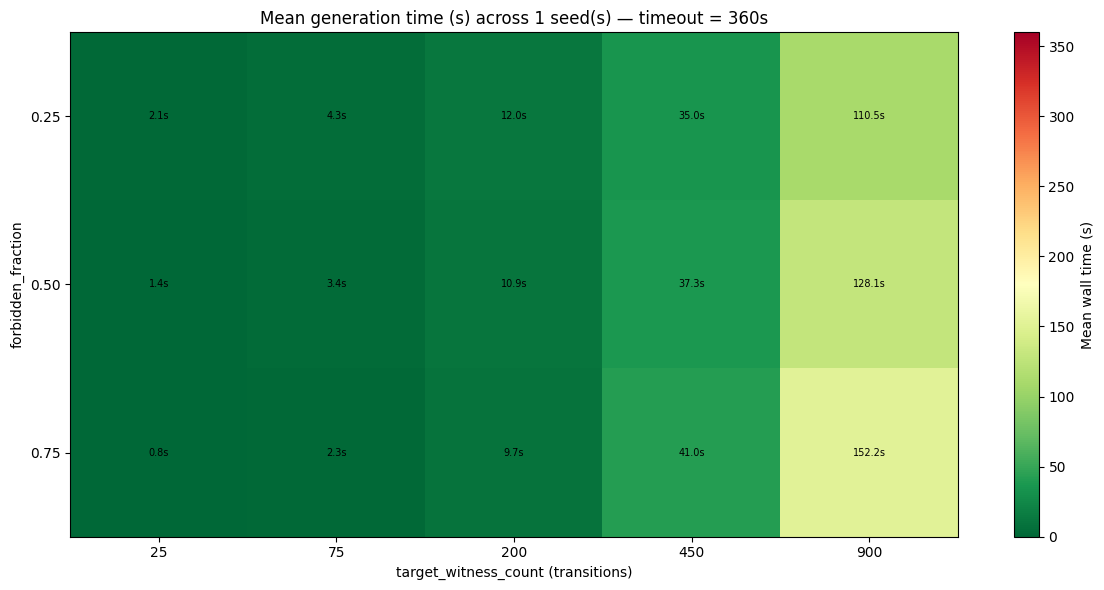

In [17]:
# ── 1. Mean generation time ───────────────────────────────────────────────────
time_pivot = df_agg.pivot(index="fraction", columns="transitions", values="elapsed_mean")
data = time_pivot.values.astype(float)

fig, ax = plt.subplots(figsize=(12, 6))
im = ax.imshow(data, cmap="RdYlGn_r", vmin=0, vmax=TIMEOUT_SECONDS, aspect="auto")
fig.colorbar(im, ax=ax, label="Mean wall time (s)")

for i in range(data.shape[0]):
    for j in range(data.shape[1]):
        ax.text(j, i, f"{data[i, j]:.1f}s", ha="center", va="center", fontsize=7)

_set_heatmap_ticks(ax)
ax.set_title(f"Mean generation time (s) across {len(RUN_SEEDS)} seed(s) — timeout = {TIMEOUT_SECONDS}s")
plt.tight_layout()
plt.show()

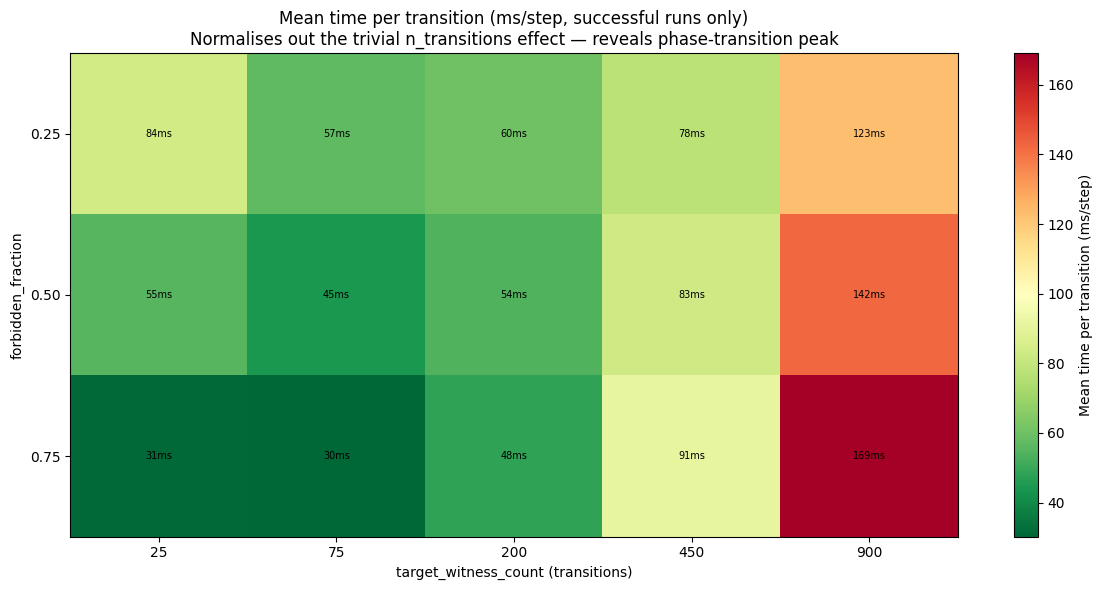

In [18]:
# ── 2. Time per transition (ms/step, successful runs only) ────────────────────
tpt_pivot = df_agg.pivot(index="fraction", columns="transitions", values="time_per_trans_mean")
data = tpt_pivot.values.astype(float)          # NaN where no seed succeeded
data_ms = data * 1000                          # convert to ms

fig, ax = plt.subplots(figsize=(12, 6))
im = ax.imshow(np.ma.masked_invalid(data_ms), cmap="RdYlGn_r", aspect="auto")
fig.colorbar(im, ax=ax, label="Mean time per transition (ms/step)")

for i in range(data_ms.shape[0]):
    for j in range(data_ms.shape[1]):
        val = data_ms[i, j]
        label = f"{val:.0f}ms" if not np.isnan(val) else "N/A"
        ax.text(j, i, label, ha="center", va="center", fontsize=7)

_set_heatmap_ticks(ax)
ax.set_title(
    "Mean time per transition (ms/step, successful runs only)\n"
    "Normalises out the trivial n_transitions effect — reveals phase-transition peak"
)
plt.tight_layout()
plt.show()

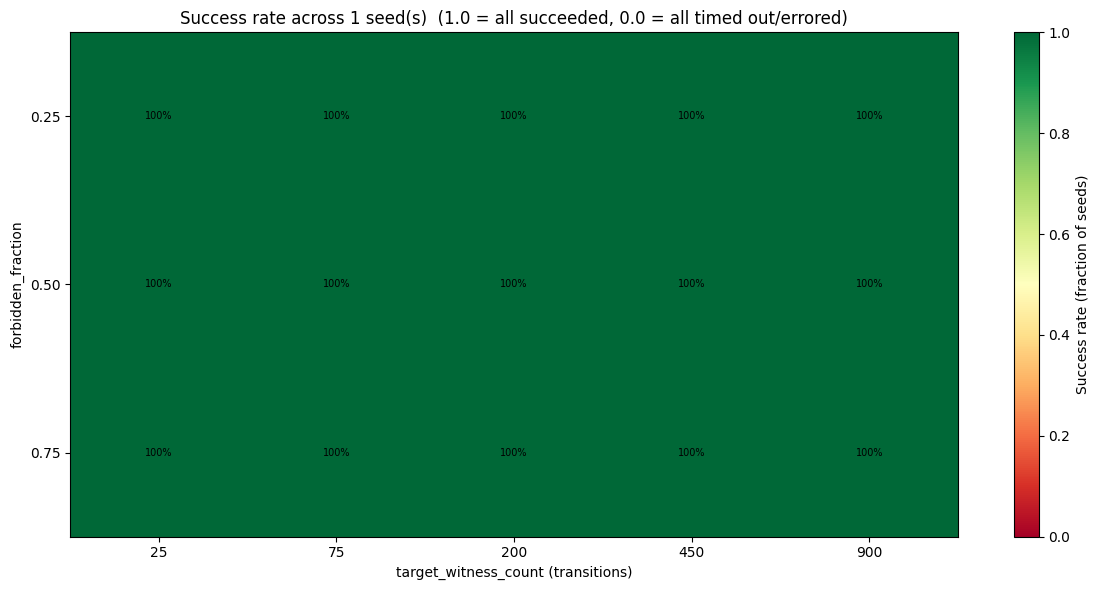

In [19]:
# ── 3. Success rate ───────────────────────────────────────────────────────────
sr_pivot = df_agg.pivot(index="fraction", columns="transitions", values="success_rate")
data = sr_pivot.values.astype(float)

fig, ax = plt.subplots(figsize=(12, 6))
im = ax.imshow(data, cmap="RdYlGn", vmin=0, vmax=1, aspect="auto")
fig.colorbar(im, ax=ax, label="Success rate (fraction of seeds)")

for i in range(data.shape[0]):
    for j in range(data.shape[1]):
        ax.text(j, i, f"{data[i, j]:.0%}", ha="center", va="center", fontsize=7)

_set_heatmap_ticks(ax)
ax.set_title(f"Success rate across {len(RUN_SEEDS)} seed(s)  (1.0 = all succeeded, 0.0 = all timed out/errored)")
plt.tight_layout()
plt.show()

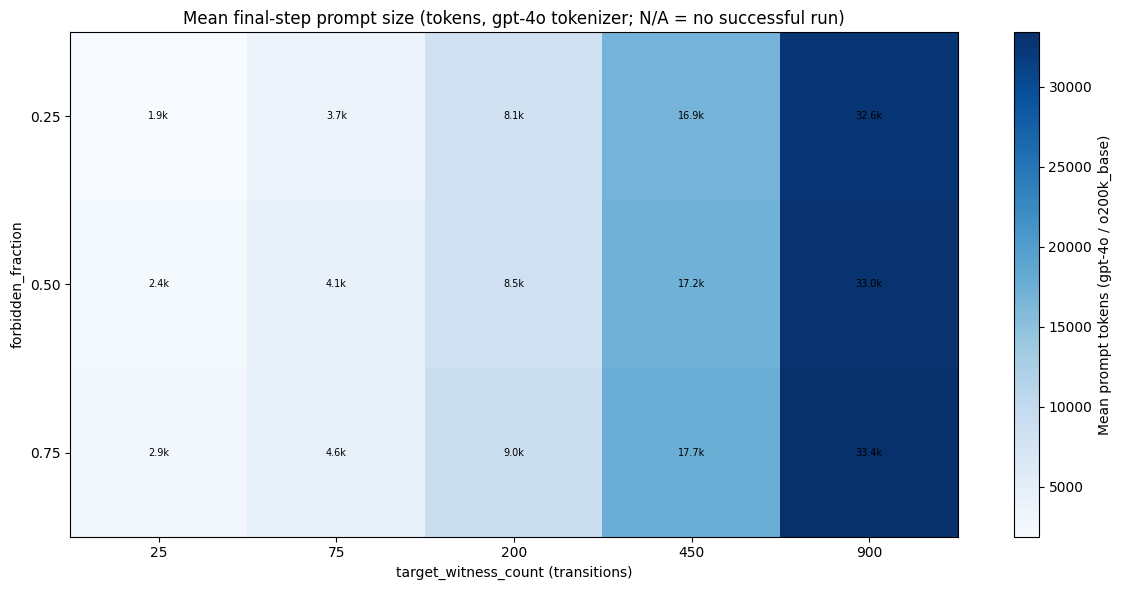

In [20]:
# ── 4. Prompt token count (tiktoken / gpt-4o, final step, successful runs) ────
tok_pivot = df_agg.pivot(index="fraction", columns="transitions", values="prompt_tokens_mean")
data = tok_pivot.values.astype(float)

fig, ax = plt.subplots(figsize=(12, 6))
im = ax.imshow(np.ma.masked_invalid(data), cmap="Blues", aspect="auto")
fig.colorbar(im, ax=ax, label="Mean prompt tokens (gpt-4o / o200k_base)")

for i in range(data.shape[0]):
    for j in range(data.shape[1]):
        val = data[i, j]
        label = f"{val / 1000:.1f}k" if not np.isnan(val) else "N/A"
        ax.text(j, i, label, ha="center", va="center", fontsize=7)

_set_heatmap_ticks(ax)
ax.set_title("Mean final-step prompt size (tokens, gpt-4o tokenizer; N/A = no successful run)")
plt.tight_layout()
plt.show()

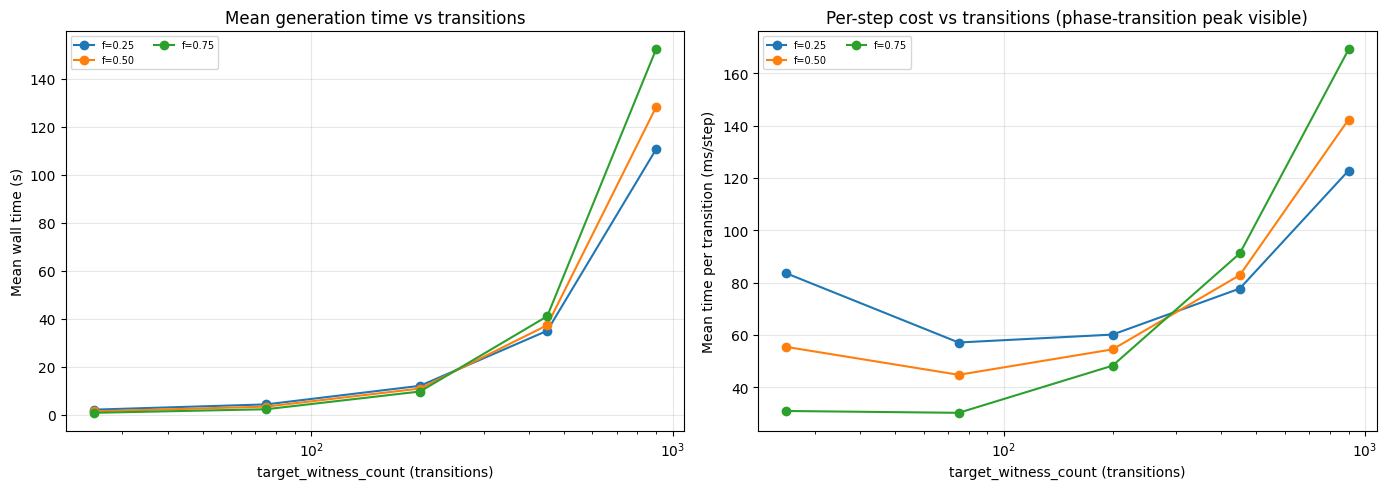

In [21]:
# ── 5. Scaling line plots (mean over seeds, successful runs only) ──────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
for fraction in FORBIDDEN_FRACTIONS:
    sub = df_agg[df_agg["fraction"] == fraction].sort_values("transitions")
    mask = sub["success_rate"] > 0   # at least one seed succeeded
    sub = sub[mask]
    if not sub.empty:
        ax.plot(sub["transitions"], sub["elapsed_mean"], marker="o", label=f"f={fraction:.2f}")
ax.set_xscale("log")
ax.set_xlabel("target_transition_count (transitions)")
ax.set_ylabel("Mean wall time (s)")
ax.set_title("Mean generation time vs transitions")
ax.legend(fontsize=7, ncol=2)
ax.grid(True, alpha=0.3)

ax = axes[1]
for fraction in FORBIDDEN_FRACTIONS:
    sub = df_agg[df_agg["fraction"] == fraction].sort_values("transitions")
    mask = sub["time_per_trans_mean"].notna()
    sub = sub[mask]
    if not sub.empty:
        ax.plot(sub["transitions"], sub["time_per_trans_mean"] * 1000, marker="o", label=f"f={fraction:.2f}")
ax.set_xscale("log")
ax.set_xlabel("target_transition_count (transitions)")
ax.set_ylabel("Mean time per transition (ms/step)")
ax.set_title("Per-step cost vs transitions (phase-transition peak visible)")
ax.legend(fontsize=7, ncol=2)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Search complexity analysis

These cells use the `search_log` recorded at each transition step.  Every step the generator
scores up to `top_template_count` candidate slots and calls the OR-Tools CP-SAT solver for
each in turn until one succeeds.  A `solver_attempt` can end in three ways:

| Status | Meaning |
|---|---|
| `solved` | CSP found a valid sequence — the move is accepted |
| `no_solution` | Automaton constraint proved the slot infeasible (fast) |
| `validator_failed` | Sequence was generated but rejected by the cross-word validator |

The number of attempts before the first `solved` is the per-transition search cost.

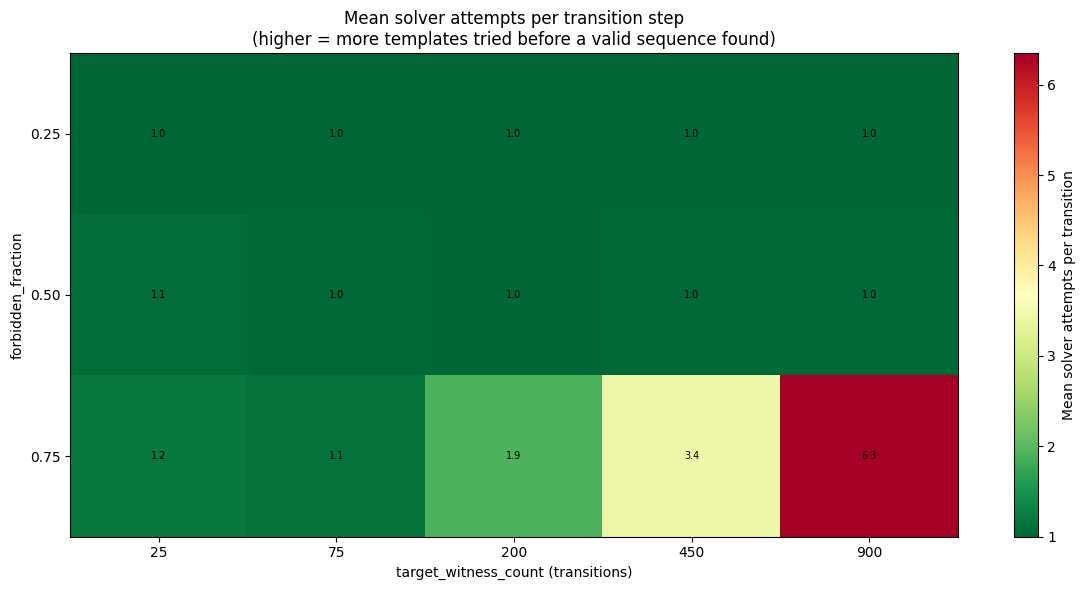

In [22]:
# ── 6. Average attempts per transition (heatmap) ──────────────────────────────
# Shows how many CSP solver calls are needed per board step on average.
att_pivot = df_agg.pivot(index="fraction", columns="transitions", values="avg_attempts_per_trans")
data = att_pivot.values.astype(float)

fig, ax = plt.subplots(figsize=(12, 6))
im = ax.imshow(np.ma.masked_invalid(data), cmap="RdYlGn_r", aspect="auto")
fig.colorbar(im, ax=ax, label="Mean solver attempts per transition")

for i in range(data.shape[0]):
    for j in range(data.shape[1]):
        val = data[i, j]
        label = f"{val:.1f}" if not np.isnan(val) else "N/A"
        ax.text(j, i, label, ha="center", va="center", fontsize=7)

_set_heatmap_ticks(ax)
ax.set_title(
    "Mean solver attempts per transition step\n"
    "(higher = more templates tried before a valid sequence found)"
)
plt.tight_layout()
plt.show()

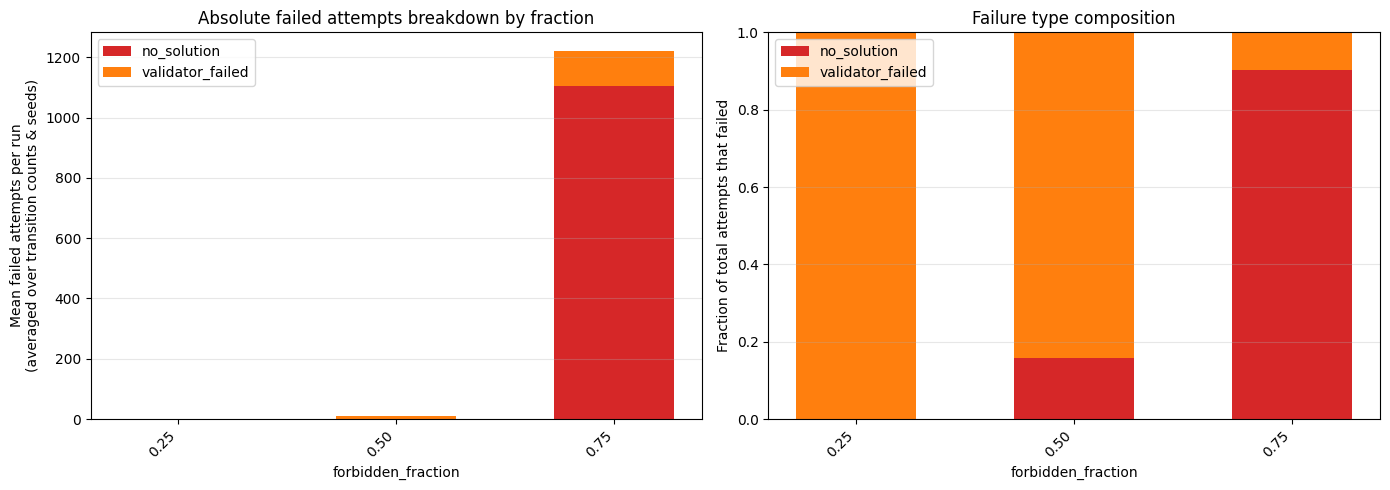

In [23]:
# ── 7. Failure breakdown: no_solution vs validator_failed (stacked bars) ───────
# Aggregated across all transition counts per fraction — absolute totals per run.
breakdown = (
    df_raw[df_raw["status"] == "success"]
    .groupby("fraction")[["total_no_solution", "total_validator_failed"]]
    .mean()   # mean across seeds and transition counts
    .reset_index()
)

x     = np.arange(len(breakdown))
w     = 0.55
bot   = breakdown["total_no_solution"].values
top_v = breakdown["total_validator_failed"].values

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: absolute counts
ax = axes[0]
bars_ns = ax.bar(x, bot,       w, label="no_solution",      color="#d62728")
bars_vf = ax.bar(x, top_v, w, bottom=bot, label="validator_failed", color="#ff7f0e")
ax.set_xticks(x)
ax.set_xticklabels([f"{f:.2f}" for f in breakdown["fraction"]], rotation=45, ha="right")
ax.set_xlabel("forbidden_fraction")
ax.set_ylabel("Mean failed attempts per run\n(averaged over transition counts & seeds)")
ax.set_title("Absolute failed attempts breakdown by fraction")
ax.legend()
ax.grid(axis="y", alpha=0.3)

# Right: fraction of total attempts that failed
total = bot + top_v
frac_ns = np.where(total > 0, bot  / total, 0)
frac_vf = np.where(total > 0, top_v / total, 0)

ax = axes[1]
ax.bar(x, frac_ns, w, label="no_solution",      color="#d62728")
ax.bar(x, frac_vf, w, bottom=frac_ns, label="validator_failed", color="#ff7f0e")
ax.set_xticks(x)
ax.set_xticklabels([f"{f:.2f}" for f in breakdown["fraction"]], rotation=45, ha="right")
ax.set_xlabel("forbidden_fraction")
ax.set_ylabel("Fraction of total attempts that failed")
ax.set_title("Failure type composition")
ax.set_ylim(0, 1)
ax.legend()
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

/var/folders/01/4z7h002d20qdhxmb_fvjwnf00000gn/T/ipykernel_27376/1091237547.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(groups, labels=labels, patch_artist=True,


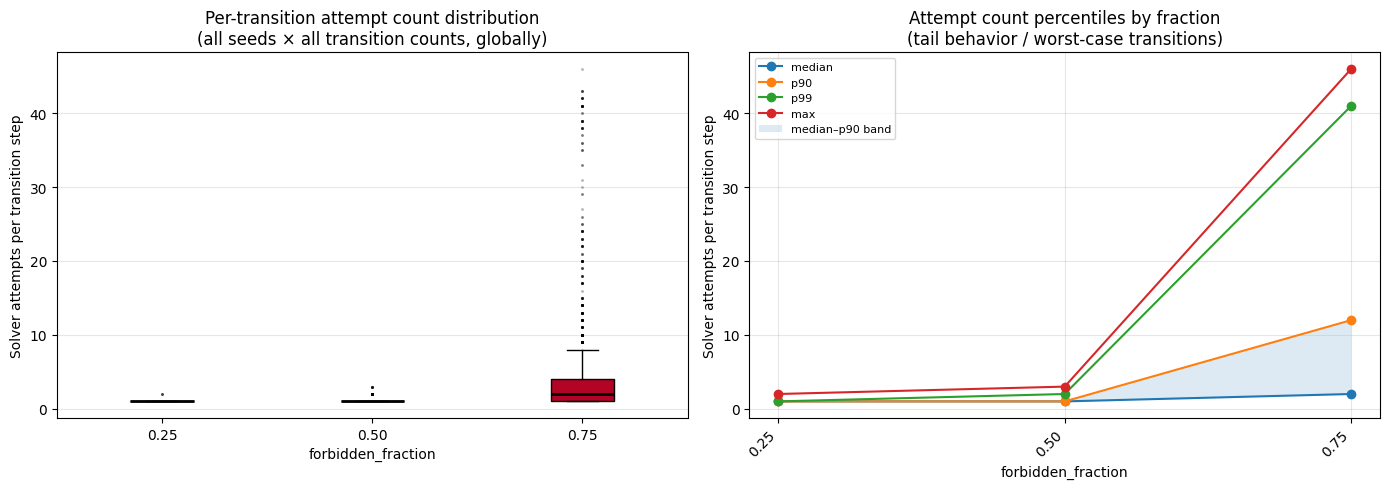

 fraction  count     mean      std  min  25%  50%  75%  90%  99%  max
     0.25 1650.0 1.002424 0.049192  1.0  1.0  1.0  1.0  1.0  1.0  2.0
     0.50 1650.0 1.026667 0.188876  1.0  1.0  1.0  1.0  1.0  2.0  3.0
     0.75 1650.0 4.701212 7.667661  1.0  1.0  2.0  4.0 12.0 41.0 46.0


In [24]:
# ── 8. Per-transition attempt count distribution (box plots, global) ───────────
# df_dist has one row per transition step across ALL (seed, transitions) combinations.
# Collapsing transition count shows the grammar-difficulty effect on per-step search cost.
if not df_dist.empty:
    fractions_present = sorted(df_dist["fraction"].unique())
    groups = [df_dist[df_dist["fraction"] == f]["n_attempts"].values for f in fractions_present]
    labels = [f"{f:.2f}" for f in fractions_present]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Left: box plot of n_attempts per individual transition step, grouped by fraction
    ax = axes[0]
    bp = ax.boxplot(groups, labels=labels, patch_artist=True,
                    medianprops=dict(color="black", linewidth=2),
                    flierprops=dict(marker=".", markersize=2, alpha=0.3))
    cmap = plt.cm.coolwarm
    for i, patch in enumerate(bp["boxes"]):
        patch.set_facecolor(cmap(i / max(len(groups) - 1, 1)))
    ax.set_xlabel("forbidden_fraction")
    ax.set_ylabel("Solver attempts per transition step")
    ax.set_title("Per-transition attempt count distribution\n(all seeds × all transition counts, globally)")
    ax.grid(axis="y", alpha=0.3)

    # Right: percentile table as a line plot (median, p90, p99, max)
    ax = axes[1]
    pcts = {
        "median": [np.median(g) for g in groups],
        "p90":    [np.percentile(g, 90) for g in groups],
        "p99":    [np.percentile(g, 99) for g in groups],
        "max":    [np.max(g)            for g in groups],
    }
    x = np.arange(len(fractions_present))
    for label, vals in pcts.items():
        ax.plot(x, vals, marker="o", label=label)
    ax.fill_between(x, pcts["median"], pcts["p90"], alpha=0.15, label="median–p90 band")
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=45, ha="right")
    ax.set_xlabel("forbidden_fraction")
    ax.set_ylabel("Solver attempts per transition step")
    ax.set_title("Attempt count percentiles by fraction\n(tail behavior / worst-case transitions)")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()
    print(df_dist_summary.to_string(index=False))
else:
    print("No search log data available (no successful runs or include_search_logs was False).")